# Figure S3

Compact full-nucleotide G_mu decay checks for the Figure 6 D-F mutation models. Rows are mutation models and columns are empirical landscapes.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import pickle
from pathlib import Path

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.figure import Figure

from slide.direvo_functions import get_single_decay_rate_IK_v2, model_function_IK_v2
from slide.utils import (
    FIGURE_LABEL_SIZE,
    FIGURE_LEGEND_SIZE,
    FIGURE_TICK_SIZE,
    FIGURE_TITLE_SIZE,
    PANEL_LETTER_SIZE,
    get_figures_dir,
    get_processed_data_dir,
    get_raw_data_dir,
    load_pickle,
    save_pickle,
)

OVERWRITE_PROCESSED_PKL: bool = True
PLOT_ONLY: bool = False
SAVE_FIGURES: bool = True
PANEL_DPI: int = 350
SAVE_TYPES: tuple[str, ...] = ("pdf", "png", "eps")

RAW_DATA_DIR = get_raw_data_dir()
PROCESSED_DATA_DIR = get_processed_data_dir()
FIGURES_DIR = get_figures_dir()
MODEL_KEYS: tuple[str, ...] = (
    "nuc_uniform",
    "nuc_e_coli_weighted",
    "nuc_e_coli_directed",
    "nuc_a_thaliana_weighted",
    "nuc_a_thaliana_directed",
)
MODEL_TITLES: dict[str, str] = {
    "nuc_uniform": "Uniform",
    "nuc_e_coli_weighted": r"Weighted $\mathit{E.\ coli}$",
    "nuc_e_coli_directed": r"Directed $\mathit{E.\ coli}$",
    "nuc_a_thaliana_weighted": r"Weighted $\mathit{A.\ thaliana}$",
    "nuc_a_thaliana_directed": r"Directed $\mathit{A.\ thaliana}$",
}
LANDSCAPE_KEYS: tuple[str, ...] = ("gb1", "trpb", "tev", "pard3")
LANDSCAPE_NAMES: tuple[str, ...] = ("GB1", "TrpB", "TEV", "ParD3")
COMPACT_RAW_PATHS: dict[tuple[str, str], Path] = {
    (model, landscape): RAW_DATA_DIR / f"figure6_full_nuc_gmu_{landscape}_{model}_raw.pkl"
    for model in MODEL_KEYS
    for landscape in LANDSCAPE_KEYS
}
ANALYTICS_PATHS: dict[str, Path] = {
    landscape: PROCESSED_DATA_DIR / f"figure6_full_nuc_gmu_{landscape}_kernel_analytics_processed.pkl"
    for landscape in LANDSCAPE_KEYS
}
PROCESSED_PATH = PROCESSED_DATA_DIR / "figureS3_compact_full_nuc_decay_curves_processed.pkl"
NUM_GENERATIONS: int = 75
TOTAL_MUTATION_RATE: float = 0.1

print(f"raw_data: {RAW_DATA_DIR}")
print(f"processed_data: {PROCESSED_DATA_DIR}")
print(f"processed path: {PROCESSED_PATH}")


raw_data: /home/lady5906/workspace_python/SLIDE/raw_data
processed_data: /home/lady5906/workspace_python/SLIDE/processed_data
processed path: /home/lady5906/workspace_python/SLIDE/processed_data/figureS3_compact_full_nuc_decay_curves_processed.pkl


## Utilities

In [2]:
class NumpyCompatUnpickler(pickle.Unpickler):
    """Unpickle NumPy-2 payloads from a local NumPy-1 environment.

    Parameters:
    - pickle.Unpickler: pickle.Unpickler
        Base unpickler receiving an opened binary pickle handle.

    Returns:
    - None
        Instances remap private NumPy module paths during class lookup.
    """

    def find_class(self, module: str, name: str) -> object:
        """Return a pickle class, remapping NumPy private module paths.

        Parameters:
        - module: str
            Module path stored in the pickle.
        - name: str
            Class or function name stored in the pickle.

        Returns:
        - object
            Class or function resolved for unpickling.
        """
        if module.startswith("numpy._core"):
            module = module.replace("numpy._core", "numpy.core", 1)
        return super().find_class(module, name)


def load_compatible_pickle(path: str | Path) -> object:
    """Load a pickle, accepting NumPy-2 array payloads in NumPy-1.

    Parameters:
    - path: str | Path
        Pickle file to read.

    Returns:
    - object
        Deserialized payload.
    """
    with Path(path).open("rb") as handle:
        return NumpyCompatUnpickler(handle).load()


def save_figure(fig: Figure, stem: str, *, bbox_inches: str = "tight") -> None:
    """Save one figure in every configured format.

    Parameters:
    - fig: Figure
        Figure to save.
    - stem: str
        Output filename stem.
    - bbox_inches: str
        Matplotlib bounding-box mode.

    Returns:
    - None
        Files are written below ``FIGURES_DIR``.
    """
    for suffix in SAVE_TYPES:
        destination = FIGURES_DIR / suffix
        destination.mkdir(parents=True, exist_ok=True)
        fig.savefig(destination / f"{stem}.{suffix}", dpi=PANEL_DPI, bbox_inches=bbox_inches)


def add_panel_letter(ax: Axes, letter: str) -> None:
    """Add a manuscript panel letter.

    Parameters:
    - ax: Axes
        Axis receiving the label.
    - letter: str
        Panel letter.

    Returns:
    - None
        The axis is modified in place.
    """
    ax.text(-0.18, 1.10, letter, transform=ax.transAxes, fontsize=PANEL_LETTER_SIZE, fontweight="bold", va="top", ha="left")


## Raw Product Check

In [3]:
def report_compact_inputs() -> tuple[list[Path], list[Path]]:
    """Print compact G_mu and analytical payload availability.

    Parameters:
    - None

    Returns:
    - tuple[list[Path], list[Path]]
        Missing compact raw paths and missing analytical paths.
    """
    missing_raw = [path for path in COMPACT_RAW_PATHS.values() if not path.exists()]
    missing_analytics = [path for path in ANALYTICS_PATHS.values() if not path.exists()]
    print(f"Compact raw products present: {len(COMPACT_RAW_PATHS) - len(missing_raw)} / {len(COMPACT_RAW_PATHS)}")
    for path in missing_raw:
        print(f"  missing raw: {path}")
    print(f"Analytical products present: {len(ANALYTICS_PATHS) - len(missing_analytics)} / {len(ANALYTICS_PATHS)}")
    for path in missing_analytics:
        print(f"  missing analytics: {path}")
    return missing_raw, missing_analytics


missing_raw_paths, missing_analytics_paths = report_compact_inputs()


Compact raw products present: 20 / 20
Analytical products present: 4 / 4


## Processing

In [4]:
def extract_final_observed_curve(raw_payload: dict[str, object]) -> tuple[np.ndarray, np.ndarray, int]:
    """Extract the final all-start observed G_mu curve from a compact payload.

    Parameters:
    - raw_payload: dict[str, object]
        Compact full-nucleotide G_mu payload from Figure 6 D-F raw generation.

    Returns:
    - tuple[np.ndarray, np.ndarray, int]
        Mean observed G_mu curve, ordering-level curves, and final start count.
    """
    data = raw_payload["data"]
    g_mu = np.asarray(data["g_mu"], dtype=float)
    counts = np.asarray(data["counts"], dtype=int)
    if g_mu.ndim != 3 or g_mu.shape[-1] != NUM_GENERATIONS:
        raise ValueError(f"Unexpected compact G_mu shape: {g_mu.shape}.")
    if counts.ndim != 1 or g_mu.shape[1] != len(counts):
        raise ValueError("Compact G_mu count axis does not match counts.")
    final_index = int(np.argmax(counts))
    final_ordering_curves = g_mu[:, final_index, :]
    return final_ordering_curves.mean(axis=0), final_ordering_curves, int(counts[final_index])


def fit_observed_curve(observed: np.ndarray) -> tuple[np.ndarray, float, float, float]:
    """Fit the observed G_mu curve with the existing IK decay model.

    Parameters:
    - observed: np.ndarray
        One-dimensional observed G_mu curve.

    Returns:
    - tuple[np.ndarray, float, float, float]
        Fitted curve, fitted rate, fitted amplitude, and fitted constant.
    """
    curve = np.asarray(observed, dtype=float)
    if curve.ndim != 1 or len(curve) != NUM_GENERATIONS:
        raise ValueError(f"Observed curve has shape {curve.shape}.")
    if not np.all(np.isfinite(curve)) or np.isclose(curve[0], 0.0):
        raise ValueError("Observed G_mu curve is non-finite or begins at zero.")
    scale = max(float(curve[0]), 1e-10)
    normalized = curve / scale
    fitted_rate, fitted_amplitude, fitted_constant = get_single_decay_rate_IK_v2(
        normalized, mut=TOTAL_MUTATION_RATE, num_steps=NUM_GENERATIONS
    )
    generations = np.arange(NUM_GENERATIONS, dtype=float)
    fitted = model_function_IK_v2(
        generations,
        fitted_rate,
        fitted_amplitude * scale,
        fitted_constant * scale,
        mut=TOTAL_MUTATION_RATE,
    )
    return fitted, float(fitted_rate), float(fitted_amplitude * scale), float(fitted_constant * scale)


def analytical_idealised_curve(observed: np.ndarray, analytical: dict[str, object]) -> tuple[np.ndarray, float, float]:
    """Build the analytical idealized G_mu decay curve.

    Parameters:
    - observed: np.ndarray
        One-dimensional observed G_mu curve.
    - analytical: dict[str, object]
        Analytical rho_2/G_infinity payload for one landscape and model.

    Returns:
    - tuple[np.ndarray, float, float]
        Idealized curve, analytical rho_2, and analytical G_infinity.
    """
    rho_2 = float(analytical["rho_2"])
    g_infinity = float(analytical["G_infinity"])
    generations = np.arange(NUM_GENERATIONS, dtype=float)
    accumulated_mutations = TOTAL_MUTATION_RATE * generations
    idealised = (float(observed[0]) - g_infinity) * np.exp(-2.0 * accumulated_mutations * rho_2) + g_infinity
    return idealised, rho_2, g_infinity


def process_s3_payload() -> dict[str, object]:
    """Process compact Figure 6 D-F G_mu payloads into Figure S3 curves.

    Parameters:
    - None

    Returns:
    - dict[str, object]
        Observed, fitted, and analytical idealized curves for available panels.
    """
    panels: dict[tuple[str, str], dict[str, object]] = {}
    missing: list[str] = []
    for landscape_key, landscape_name in zip(LANDSCAPE_KEYS, LANDSCAPE_NAMES, strict=True):
        analytics_path = ANALYTICS_PATHS[landscape_key]
        if not analytics_path.exists():
            missing.append(str(analytics_path))
            continue
        analytics_payload = load_compatible_pickle(analytics_path)
        analytics_data = analytics_payload["data"][landscape_name]
        for model in MODEL_KEYS:
            raw_path = COMPACT_RAW_PATHS[(model, landscape_key)]
            if not raw_path.exists():
                missing.append(str(raw_path))
                continue
            raw_payload = load_compatible_pickle(raw_path)
            observed, ordering_curves, final_count = extract_final_observed_curve(raw_payload)
            fitted, fitted_rate, fitted_amplitude, fitted_constant = fit_observed_curve(observed)
            idealised, rho_2, g_infinity = analytical_idealised_curve(observed, analytics_data[model])
            panels[(model, landscape_name)] = {
                "observed": observed,
                "observed_ordering_curves": ordering_curves,
                "observed_ordering_std": ordering_curves.std(axis=0, ddof=1),
                "fitted": fitted,
                "idealised": idealised,
                "analytical_constant": g_infinity,
                "fitted_constant": fitted_constant,
                "fitted_rate": fitted_rate,
                "fitted_amplitude": fitted_amplitude,
                "rho_2": rho_2,
                "final_start_count": final_count,
                "raw_path": str(raw_path),
                "analytics_path": str(analytics_path),
            }
    return {
        "data": panels,
        "params": {
            "models": MODEL_KEYS,
            "landscapes": LANDSCAPE_KEYS,
            "landscape_names": LANDSCAPE_NAMES,
            "M": NUM_GENERATIONS,
            "total_mutation_rate": TOTAL_MUTATION_RATE,
            "compact_raw_paths": {str(key): str(value) for key, value in COMPACT_RAW_PATHS.items()},
            "analytics_paths": {key: str(value) for key, value in ANALYTICS_PATHS.items()},
        },
        "metadata": {
            "paper_reference": "Figure S3",
            "raw_products": "compact Figure 6 D-F full-nucleotide G_mu payloads in raw_data",
            "observed_definition": "Final-count compact G_mu curve, averaged across deterministic start orderings.",
            "missing_inputs": missing,
        },
    }


if PROCESSED_PATH.exists() and (PLOT_ONLY or not OVERWRITE_PROCESSED_PKL):
    figure_s3_payload = load_pickle(PROCESSED_PATH)
elif PLOT_ONLY:
    raise FileNotFoundError(f"PLOT_ONLY=True requires {PROCESSED_PATH}. Set PLOT_ONLY=False to process available compact raw products.")
else:
    figure_s3_payload = process_s3_payload()
    save_pickle(figure_s3_payload, PROCESSED_PATH)

print(f"Processed S3 panels available: {len(figure_s3_payload['data'])} / {len(MODEL_KEYS) * len(LANDSCAPE_KEYS)}")
for missing_path in figure_s3_payload["metadata"].get("missing_inputs", []):
    print(f"missing: {missing_path}")


Processed S3 panels available: 20 / 20


## Plot

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


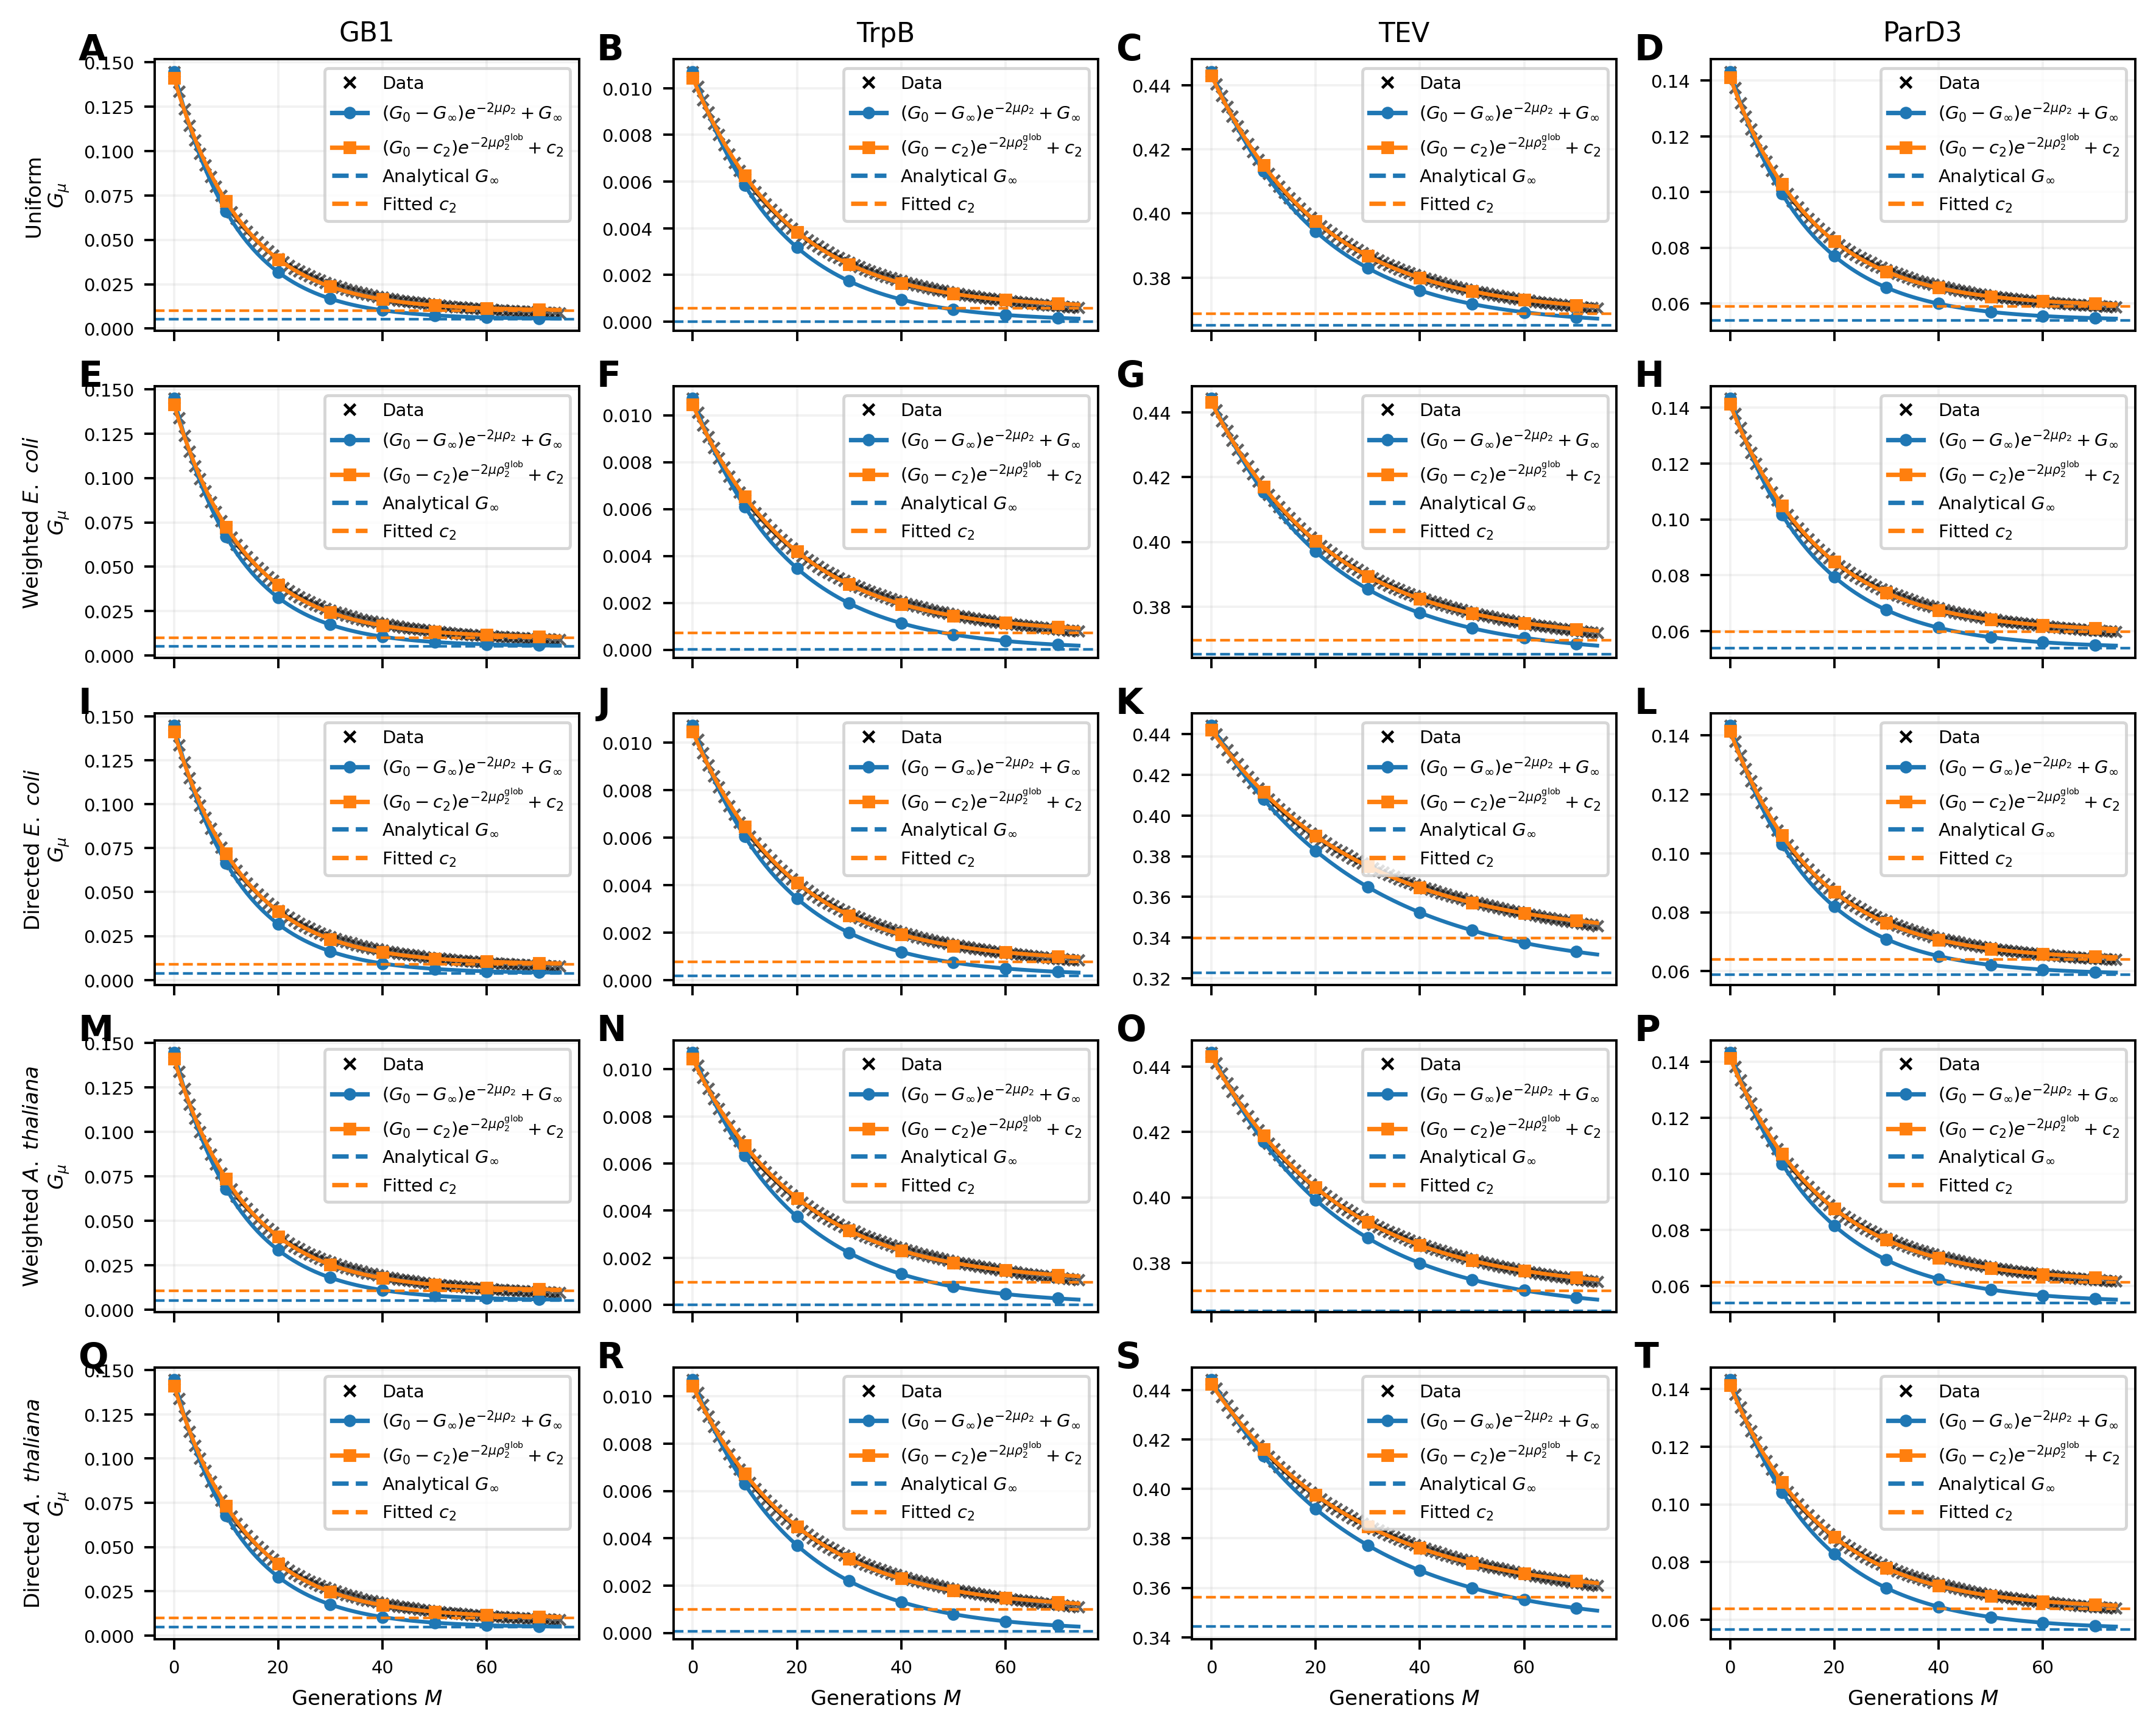

In [ ]:
def plot_s3_panel(ax: Axes, payload: dict[str, object], model: str, landscape: str) -> None:
    """Plot observed, fitted, and analytical idealized squared-fitness decay.

    Parameters:
    - ax: Axes
        Axis receiving the panel.
    - payload: dict[str, object]
        Processed Figure S3 payload.
    - model: str
        Mutation model key.
    - landscape: str
        Empirical landscape name.

    Returns:
    - None
        Artists are added to the axis.
    """
    panel = payload["data"].get((model, landscape))
    if panel is None:
        ax.text(0.5, 0.5, "missing", transform=ax.transAxes, ha="center", va="center", fontsize=FIGURE_LABEL_SIZE)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_frame_on(False)
        return
    generations = np.arange(len(panel["observed"]))
    observed = np.asarray(panel["observed"], dtype=float)
    observed_std = np.asarray(panel["observed_ordering_std"], dtype=float)
    ax.plot(generations, observed, color="black", marker="x", linestyle="None", markersize=3.6, alpha=0.62, label="Data")
    ax.fill_between(generations, observed - observed_std, observed + observed_std, color="black", alpha=0.08, linewidth=0)
    ax.plot(generations, panel["idealised"], color="tab:blue", marker="o", markevery=10, markersize=3.2, linestyle="-", linewidth=1.3, label=r"$(G_0 - G_\infty) e^{-2\mu\rho_2} + G_\infty$")
    ax.plot(generations, panel["fitted"], color="tab:orange", marker="s", markevery=10, markersize=3.2, linestyle="-", linewidth=1.3, label=r"$(G_0 - c_2) e^{-2\mu\rho_2^{\mathrm{glob}}} + c_2$")
    ax.axhline(panel["analytical_constant"], color="tab:blue", linestyle="--", linewidth=0.9, label=r"Analytical $G_\infty$")
    ax.axhline(panel["fitted_constant"], color="tab:orange", linestyle="--", linewidth=0.9, label=r"Fitted $c_2$")
    ax.tick_params(labelsize=FIGURE_TICK_SIZE)
    ax.grid(True, alpha=0.16)
    legend_handles = [
        mlines.Line2D([], [], color="black", marker="x", linestyle="None", markersize=3.6, label="Data"),
        mlines.Line2D([], [], color="tab:blue", marker="o", linestyle="-", markersize=3.2, label=r"$(G_0 - G_\infty) e^{-2\mu\rho_2} + G_\infty$"),
        mlines.Line2D([], [], color="tab:orange", marker="s", linestyle="-", markersize=3.2, label=r"$(G_0 - c_2) e^{-2\mu\rho_2^{\mathrm{glob}}} + c_2$"),
        mlines.Line2D([], [], color="tab:blue", linestyle="--", label=r"Analytical $G_\infty$"),
        mlines.Line2D([], [], color="tab:orange", linestyle="--", label=r"Fitted $c_2$"),
    ]
    ax.legend(handles=legend_handles, fontsize=FIGURE_LEGEND_SIZE, loc="upper right", ncol=1)


fig, axes = plt.subplots(len(MODEL_KEYS), len(LANDSCAPE_NAMES), figsize=(10, 8), dpi=PANEL_DPI, sharex=True, constrained_layout=True)
letters = "ABCDEFGHIJKLMNOPQRST"
for row_index, model in enumerate(MODEL_KEYS):
    for column_index, landscape in enumerate(LANDSCAPE_NAMES):
        ax = axes[row_index, column_index]
        plot_s3_panel(ax, figure_s3_payload, model, landscape)
        add_panel_letter(ax, letters[row_index * len(LANDSCAPE_NAMES) + column_index])
        if row_index == 0:
            ax.set_title(landscape, fontsize=FIGURE_TITLE_SIZE)
        if column_index == 0:
            ax.set_ylabel(MODEL_TITLES[model] + "\n" + r"$G_\mu$", fontsize=FIGURE_LABEL_SIZE)
        if row_index == len(MODEL_KEYS) - 1:
            ax.set_xlabel(r"Generations $M$", fontsize=FIGURE_LABEL_SIZE)

if SAVE_FIGURES:
    save_figure(fig, "figure_S3")
plt.show()


## Manuscript Caption

```latex
\caption{\textbf{Decay curves on empirical landscapes.} Panels show full-nucleotide squared-fitness decay curves sampled from empirical landscapes, fitted decay curves, and idealised analytical decay curves. Columns correspond to GB1, TrpB, TEV, and ParD3; rows correspond to uniform mutation, weighted \textit{E. coli} mutation, directed \textit{E. coli} mutation, weighted \textit{A. thaliana} mutation, and directed \textit{A. thaliana} mutation. Empirical amino-acid landscapes were expanded to DNA sequence space with the DNA-to-codon map, assigning invalid or stop codons to the minimum landscape fitness. For each landscape and mutation model, compact deterministic $G_\mu$ curves were computed from 20 pseudo-random start orderings and prefix sample sizes; this figure uses the largest available start count and averages the 20 ordering-level curves. Fitted curves use the exponential model fitted to the observed $G_\mu$ curve, with fitted constant term $c_2$. Idealised curves use $(G_0-G_\infty)e^{-2\mu\rho_2 t}+G_\infty$, where $G_0$ is the observed initial squared-fitness value, $\rho_2$ is the analytical product-kernel decay rate, and $G_\infty$ is the analytical stationary squared mean. For uniform and weighted symmetric mutation models, $G_\infty$ is computed from the unweighted landscape average. For directed asymmetric mutation models, $G_\infty$ is computed using the product stationary distribution of the nucleotide transition matrix. The total mutation rate is $\mu=0.1$ per sequence per generation, implemented as per-site mutation probability $0.1/N$ for $N$ nucleotide sites.}
```
